<a href="https://colab.research.google.com/github/MURALAAYYAPPA/Bank-Account-Simulation/blob/main/Mosaic%20plot%20%26%20Heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<Figure size 2000x1500 with 0 Axes>

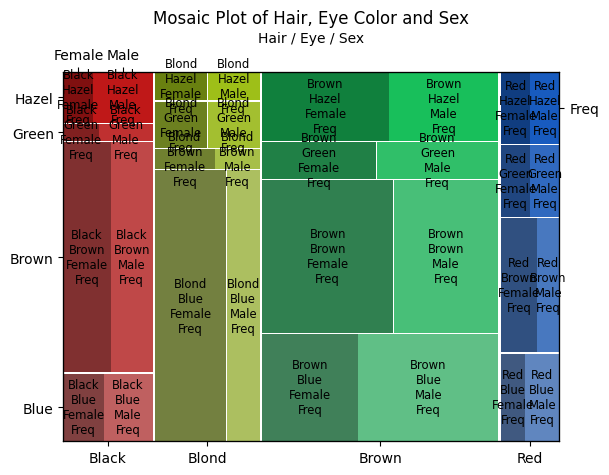

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic
data = pd.read_csv("HairEyeColor.csv")
table = data.pivot_table(
    values='Freq',
    index=['Hair', 'Eye', 'Sex'],
    aggfunc='sum'
)
plt.figure(figsize=(20,15))
mosaic(table.stack())
plt.title("Mosaic Plot of Hair, Eye Color and Sex")
plt.xlabel("Hair / Eye / Sex")
plt.ylabel("Proportion")
plt.show()


<Figure size 1000x800 with 0 Axes>

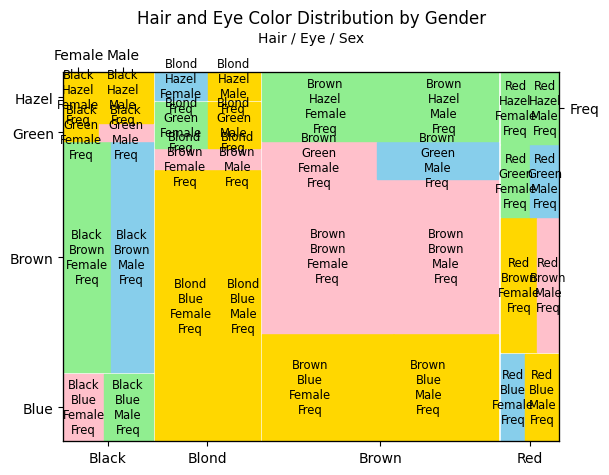

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic
data = pd.read_csv("HairEyeColor.csv")
table = data.pivot_table(
    values='Freq',
    index=['Hair', 'Eye', 'Sex'],
    aggfunc='sum'
)
colors = ["gold", "skyblue", "lightgreen", "pink"]
def props(key):
    return {"color": colors[hash(key) % len(colors)]}
plt.figure(figsize=(10,8))
mosaic(table.stack(), properties=props)
plt.title("Hair and Eye Color Distribution by Gender")
plt.xlabel("Hair / Eye / Sex")
plt.ylabel("Proportion")
plt.show()

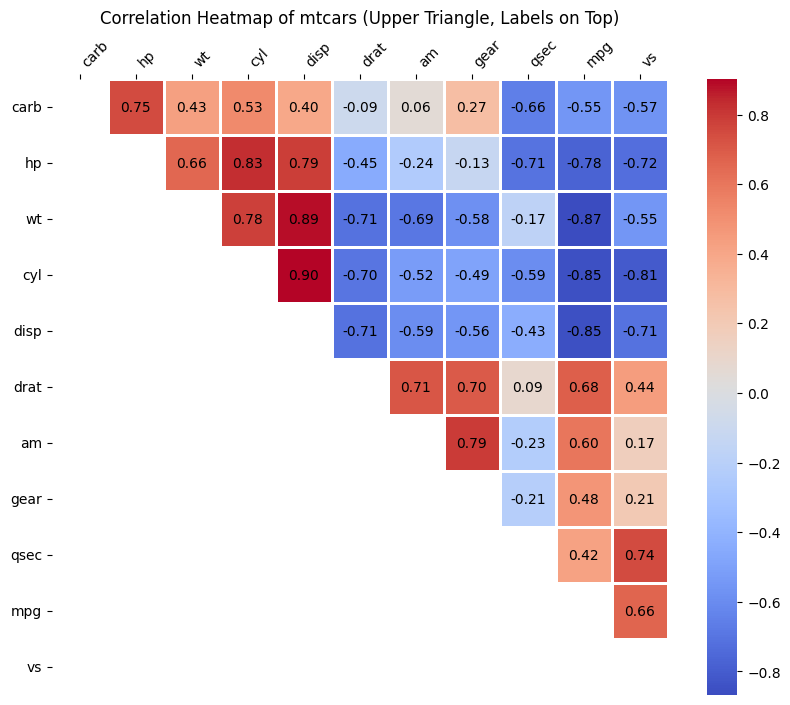

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
df = pd.read_csv("mtcars.csv", index_col=0)
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
linkage = hierarchy.linkage(corr, method='average')
dendro = hierarchy.dendrogram(linkage, no_plot=True)
order = dendro['leaves']
corr_ordered = corr.iloc[order, order]
mask = np.tril(np.ones_like(corr_ordered, dtype=bool))
plt.figure(figsize=(10,8))
ax = sns.heatmap(
    corr_ordered,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=1,
    linecolor='white',
    annot_kws={"color": "black", "fontsize":10},
    xticklabels=corr_ordered.columns,
    yticklabels=corr_ordered.columns
)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45, ha='left')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap of mtcars (Upper Triangle, Labels on Top)", pad=40)
plt.show()
